In [9]:
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import japanize_matplotlib

In [10]:
# CSVファイルを読み込み
df = pd.read_csv("../../../../input/demo/B/20251127_ryuki_02.csv")

# 必要な列があるか確認
if not set(['time','x', 'y',]).issubset(df.columns):
    raise ValueError("CSVに 'time','x', 'y',列が必要です")


# X-tグラフの描画

## データ抽出

In [11]:
# xの移動距離 = 現在のX座標 - 初期x座標
x_distance = df['x'] - df['x'].iloc[0] # iloc[n]はデータにより可変
y_distance = df['y'] - df['y'].iloc[0]


total_distance  = np.sqrt(x_distance**2 + y_distance**2)
time = df['time']

# 結果をDataFrameにまとめる
total_distance_df= pd.DataFrame({
	'time':time,
	'total_distance':total_distance,
	})

print(total_distance_df)        


       time  total_distance
0     0.311        0.000000
1     0.561        0.420000
2     0.811        0.681542
3     1.061        0.819390
4     1.311        1.060424
..      ...             ...
113  28.561       17.029131
114  28.811       17.175384
115  29.061       17.140012
116  29.311       17.076135
117  29.562       17.012395

[118 rows x 2 columns]


## グラフの描画

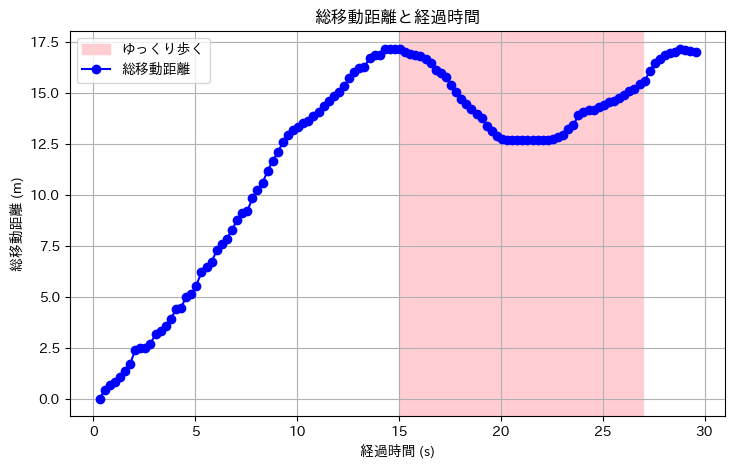

In [12]:

plt.figure(figsize=(10, 5))
plt.axvspan(15.0, 27.0,alpha=1.0,color="#ffcdd2",label='ゆっくり歩く')
plt.plot(total_distance_df['time'], total_distance_df['total_distance'], marker='o', linestyle='-', color='blue', label='総移動距離')
plt.xlabel('経過時間 (s)')
plt.ylabel('総移動距離 (m)')
plt.title('総移動距離と経過時間')
# 軸を揃える
plt.gca().set_aspect('equal', adjustable='box')
plt.grid(True)
plt.legend()

In [13]:

# 座標差分と時間差分を計算
dt = df['time'].diff()
dx = df['x'].diff()
dy = df['y'].diff()

# 各点間の移動距離 (ds) = sqrt(dx^2 + dy^2)
ds = np.sqrt(dx**2 + dy**2)

speed = ds / dt

df_speed = pd.DataFrame({
    'time': df['time'].iloc[1:].reset_index(drop=True), 
    'speed': speed.iloc[1:].reset_index(drop=True)
})

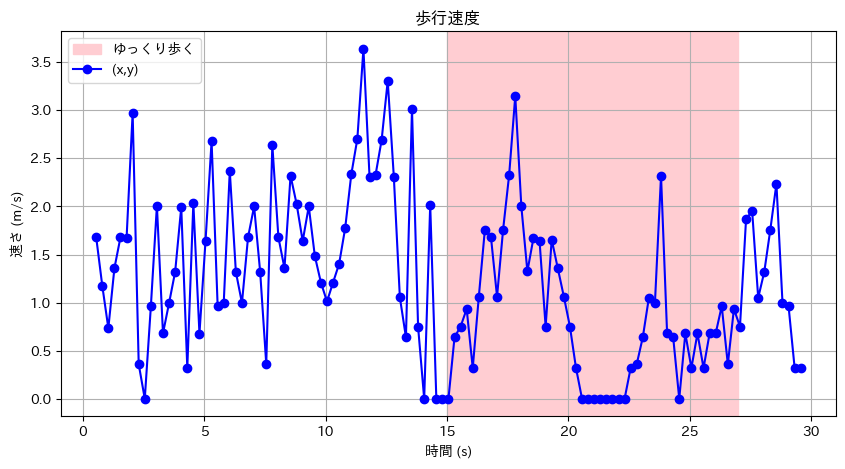

In [14]:
# 出力ファイル名
# output_csv = "speedSlowly.csv"

# CSV出力
# df_speed.to_csv(output_csv, index=False)

# 時間も1行目を除いて整形（速度と対応する時間）
speed = df_speed['speed'] 
time = df_speed['time'][1:].reset_index(drop=True)

# グラフ描画
plt.figure(figsize=(10, 5))
plt.axvspan(15.0, 27.0,alpha=1.0,color="#ffcdd2",label='ゆっくり歩く')
plt.plot(df_speed['time'], df_speed['speed'], marker='o', linestyle='-', color='blue', label='(x,y)')
plt.xlabel('時間 (s)')
plt.ylabel('速さ (m/s)')
plt.title('歩行速度')
plt.grid(True)
plt.legend()

### 赤い区間の（15.0秒から27.0秒）の平均速度の算出

In [15]:
start_time = 15.0
end_time = 27.0

# 範囲内のデータをフィルタリング
speed_filtered_range = df_speed[(df_speed['time'] >= start_time) & (df_speed['time'] <= end_time)]

# 平均速度を計算
if not speed_filtered_range.empty:
    average_speed_highlight = speed_filtered_range['speed'].mean()
    print(f"\n赤い区間 ({start_time}秒から{end_time}秒) の平均歩行速度: {average_speed_highlight:.4f} m/s")
else:
    print(f"\n赤い区間 ({start_time}秒から{end_time}秒) に対応する速度データがありません。")



赤い区間 (15.0秒から27.0秒) の平均歩行速度: 0.8462 m/s


##  平滑化フィルタをかける


## 移動平均フィルタ

       time     speed  low_speed
0     0.561  1.680000        NaN
1     0.811  1.176435        NaN
2     1.061  0.734302        NaN
3     1.311  1.358234        NaN
4     1.561  1.680000   1.325794
..      ...       ...        ...
112  28.561  2.236068   1.664314
113  28.811  1.000000   1.473295
114  29.061  0.961665   1.455638
115  29.311  0.320000   1.255638
116  29.562  0.318725   0.967292

[117 rows x 3 columns]


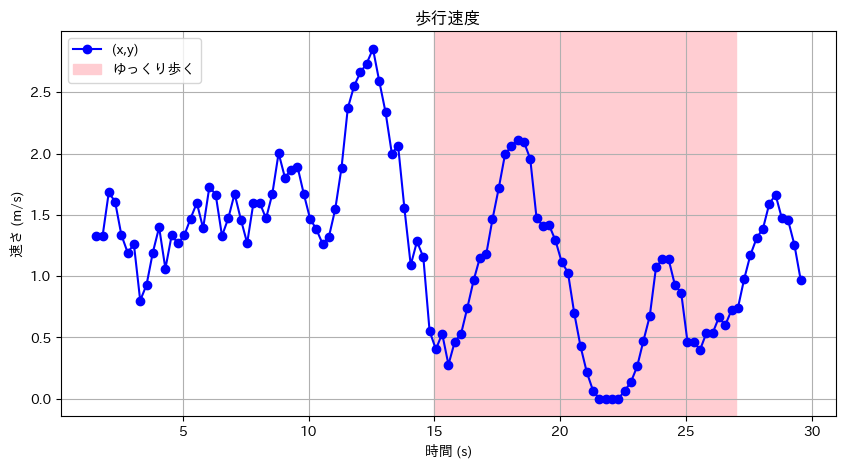

In [16]:
#　ウィンドウの宣言
window_speed=5

df_speed['low_speed']= df_speed['speed'].rolling(window=window_speed).mean()

print(df_speed)
# CSV出力
df_speed.to_csv("speed.csv", index=False)


# グラフ描画
plt.figure(figsize=(10, 5))
plt.plot(df_speed['time'], df_speed['low_speed'], marker='o', linestyle='-', color='blue', label='(x,y)')
plt.axvspan(15.0, 27.0,alpha=1.0,color="#ffcdd2",label='ゆっくり歩く')
plt.xlabel('時間 (s)')
plt.ylabel('速さ (m/s)')
plt.title('歩行速度')
plt.grid(True)
plt.legend()